# OSD — L1 Trend Filtering

Classic **L1 trend filtering** is the two-component OSD problem

$$
\min_{x^0,x^1}
\;\frac{w_0}{T}\|x^0\|_2^2 + w_1\|D_2 x^1\|_1
\quad\text{s.t.}\quad x^0+x^1=y.
$$

The second component is piecewise-linear (sparse second differences).
This notebook follows `L1-trend_OSD.ipynb` from the reference repository,
re-implemented with PySDKit’s NumPy/SciPy OSD solver.

**Reference:** Kim, Koh, Boyd, Gorinevsky, *ℓ1 Trend Filtering*, SIAM Review 2009;
Meyers & Boyd OSD monograph.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import OSD
from pysdkit._osd import MeanSquareSmall, SparseSecondDiffConvex

print(OSD())

Optimization-based Signal Decomposition (OSD)


## 1. Piecewise-linear signal + noise

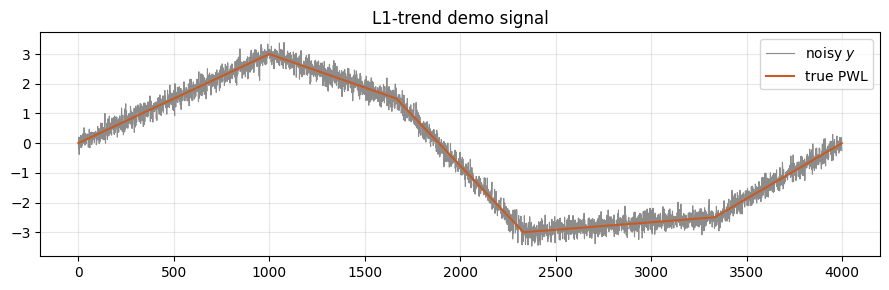

In [2]:
rng = np.random.default_rng(42)
T = 4000
aa, bb = T // 4, T // 6
pwl = np.r_[
    np.linspace(0, 3, num=aa, endpoint=False),
    np.linspace(3, 1.5, num=bb, endpoint=False),
    np.linspace(1.5, -3, num=bb, endpoint=False),
    np.linspace(-3, -2.5, num=aa, endpoint=False),
    np.linspace(-2.5, 0, num=T - 2 * (aa + bb), endpoint=False),
]
y = pwl + 0.2 * rng.standard_normal(T)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(y, color="0.55", lw=0.8, label="noisy $y$")
ax.plot(pwl, color="#c45c26", lw=1.5, label="true PWL")
ax.legend()
ax.set_title("L1-trend demo signal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Solve with OSD

In [3]:
osd = OSD.preset("l1_trend", length=T, max_iter=80)
# same as:
# OSD(components=[
#     MeanSquareSmall(size=T, weight=1 / T),
#     SparseSecondDiffConvex(weight=1.0),
# ], max_iter=80)

X = osd.fit_transform(y)
resid, trend = X[0], X[1]
print("obj:", osd.objective_value)
print(
    "||trend - truth|| / ||y - truth|| =",
    np.linalg.norm(trend - pwl) / np.linalg.norm(y - pwl),
)

obj: 7.557963064307788
||trend - truth|| / ||y - truth|| = 0.2921610047096794


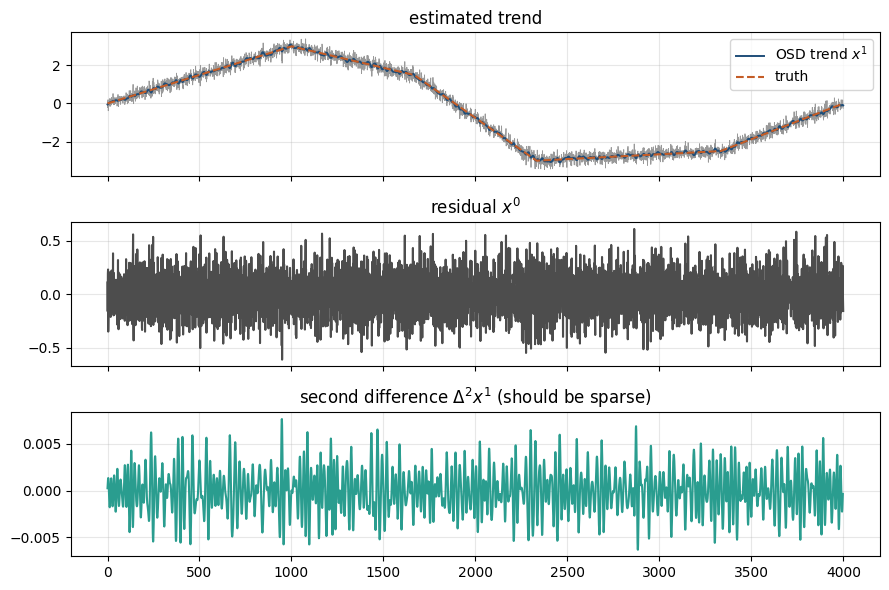

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
axes[0].plot(y, color="0.6", lw=0.6)
axes[0].plot(trend, color="#1f4e79", lw=1.4, label="OSD trend $x^1$")
axes[0].plot(pwl, "--", color="#c45c26", label="truth")
axes[0].legend(loc="upper right")
axes[0].set_title("estimated trend")
axes[1].plot(resid, color="0.3")
axes[1].set_title("residual $x^0$")
axes[2].plot(np.diff(trend, n=2), color="#2a9d8f")
axes[2].set_title(r"second difference $\Delta^2 x^1$ (should be sparse)")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Optional box constraints on the trend

The reference notebook wraps `SumAbs(diff=2)` with `Inequality(vmin, vmax)`.
In PySDKit the same idea is `vmin` / `vmax` on `SparseSecondDiffConvex`.

trend range: -2.5 2.5


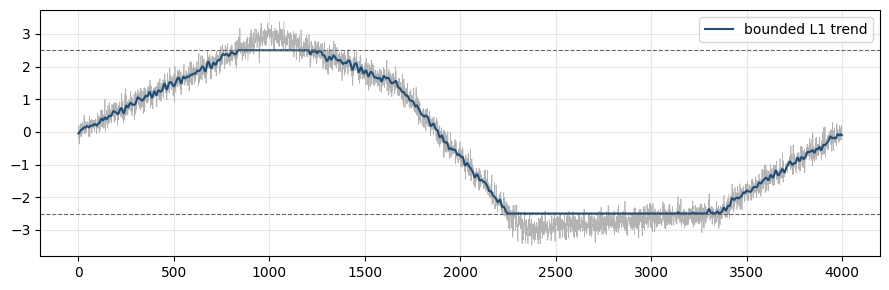

In [5]:
comps = [
    MeanSquareSmall(size=T, weight=1 / T),
    SparseSecondDiffConvex(weight=1.0, vmin=-2.5, vmax=2.5),
]
X_box = OSD(components=comps, max_iter=80).fit_transform(y)
print("trend range:", X_box[1].min(), X_box[1].max())

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(y, color="0.7", lw=0.5)
ax.plot(X_box[1], color="#1f4e79", label="bounded L1 trend")
ax.axhline(2.5, color="0.4", ls="--", lw=0.8)
ax.axhline(-2.5, color="0.4", ls="--", lw=0.8)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()